# Homework 10a — Modeling: Linear Regression

I fit a baseline linear regression on a synthetic asset-return dataset, diagnose the four regression
assumptions from its residuals, add a transformed (squared) feature, and conclude with an explicit
trust assessment that separates *prediction* from *explanation*.

The data-generating process is designed to violate two assumptions — it has a quadratic effect that
the baseline omits, and heteroskedastic noise — so the diagnostics have something real to find.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

sns.set(context='notebook', style='whitegrid')
np.random.seed(7)

## 1) Data — synthetic finance factors

Four style factors explain an asset's excess return. The *true* model includes a **quadratic term in
`momentum`** (`+3.5 * momentum^2`) and **heteroskedastic noise** whose standard deviation grows with
`|mkt_excess|`. The baseline model below omits the quadratic term, which is exactly what the residual
diagnostics are meant to catch.

In [3]:
n = 200
dates = pd.bdate_range(start='2024-02-01', periods=n)
mkt_excess = np.random.normal(0, 0.011, size=n)
size = np.random.normal(0, 0.008, size=n)
value = np.random.normal(0, 0.009, size=n)
momentum = np.random.normal(0, 0.006, size=n)

beta0, beta_mkt, beta_size, beta_value, beta_mom, beta_mom2 = 0.0001, 0.9, 0.25, -0.15, 0.35, 3.5
noise_scale = 0.0035 + 0.5 * np.abs(mkt_excess)      # heteroskedastic: variance rises with |mkt|
eps = np.random.normal(0, noise_scale)
asset_excess = (
    beta0 + beta_mkt * mkt_excess + beta_size * size + beta_value * value
    + beta_mom * momentum + beta_mom2 * (momentum ** 2) + eps
)
df = pd.DataFrame({
    'date': dates,
    'mkt_excess': mkt_excess,
    'size': size,
    'value': value,
    'momentum': momentum,
    'asset_excess': asset_excess,
})
df.head()

,date,mkt_excess,size,value,momentum,asset_excess
0,2024-02-01,0.018596,-0.013467,-0.000540,0.000141,0.014832
1,2024-02-02,-0.005125,0.008120,0.007089,-0.006840,-0.008599
2,2024-02-05,0.000361,-0.011532,-0.012885,-0.011216,-0.009577
3,2024-02-06,0.004483,-0.010749,0.003905,-0.010685,0.000033
4,2024-02-07,-0.008678,-0.002893,0.001250,0.002779,-0.005750


## 2) Baseline model fit

I split **time-ordered** (`shuffle=False`): the last 20% of the series is the test period, so the model
only ever trains on the past and predicts the future. For financial time series this is the honest
split — shuffling would let the model train on data from both sides of the test window.

In [4]:
X = df[['mkt_excess', 'size', 'value', 'momentum']]
y = df['asset_excess']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
resid = y_test - y_pred

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Baseline   R2={r2:.4f}   RMSE={rmse:.6f}')
print(f'           n_train={len(X_train)}   n_test={len(X_test)}')

true_beta = {'mkt_excess': 0.9, 'size': 0.25, 'value': -0.15, 'momentum': 0.35}
print('\nCoefficients (true beta in parentheses):')
for name, b in zip(X.columns, lr.coef_):
    print(f'  {name:12s} {b:+.4f}   (true {true_beta[name]:+.2f})')
print(f'  {"intercept":12s} {lr.intercept_:+.6f}   (true {0.0001:+.4f})')

Baseline   R2=0.3677   RMSE=0.008470
           n_train=160   n_test=40

Coefficients (true beta in parentheses):
  mkt_excess   +0.7785   (true +0.90)
  size         +0.2311   (true +0.25)
  value        -0.2099   (true -0.15)
  momentum     +0.1815   (true +0.35)
  intercept    -0.000019   (true +0.0001)


## 3) Residual diagnostics

Each of the four assumptions gets a plot. The two numbers printed below quantify what the plots show
and feed the interpretation in the next section.

In [5]:
# Quick numeric summaries of the residuals.
print('Residual summary:')
print(f'  mean={resid.mean():+.5f}  std={resid.std():.5f}  skew={st.skew(resid):+.3f}  kurtosis={st.kurtosis(resid):+.3f}')
print(f'  Shapiro-Wilk normality p-value: {st.shapiro(resid)[1]:.3f}')
het = np.corrcoef(np.abs(resid), np.abs(X_test['mkt_excess']))[0, 1]
print(f'  corr(|residual|, |mkt_excess|) = {het:+.3f}   (heteroskedasticity check)')
nl = np.corrcoef(resid, X_test['momentum'] ** 2)[0, 1]
print(f'  corr(residual, momentum^2)    = {nl:+.3f}   (linearity check)')
lag1 = np.corrcoef(resid[:-1], resid[1:])[0, 1]
print(f'  lag-1 autocorrelation         = {lag1:+.3f}   (independence check; band +/-{1.96/np.sqrt(len(resid)):.3f})')

Residual summary:
  mean=+0.00294  std=0.00804  skew=+0.510  kurtosis=+1.223
  Shapiro-Wilk normality p-value: 0.235
  corr(|residual|, |mkt_excess|) = +0.566   (heteroskedasticity check)
  corr(residual, momentum^2)    = +0.335   (linearity check)
  lag-1 autocorrelation         = +0.260   (independence check; band +/-0.310)


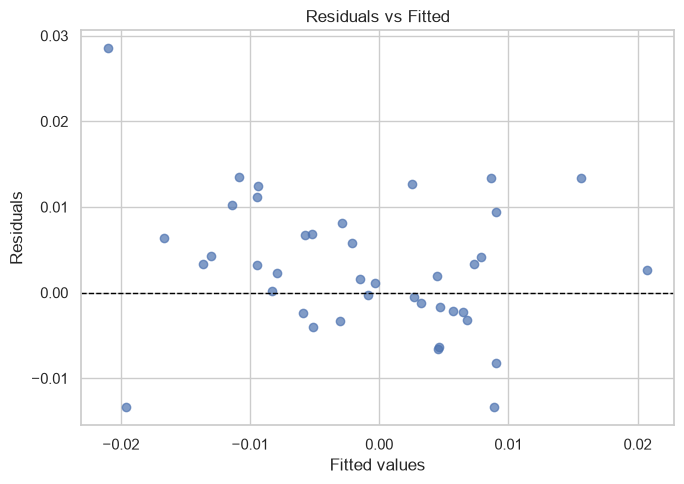

In [6]:
# Assumption 1 & 2: linearity and homoscedasticity — residuals vs fitted.
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred, resid, alpha=0.7)
ax.axhline(0, color='black', ls='--', lw=1)
ax.set_xlabel('Fitted values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')
fig.tight_layout()
plt.show()

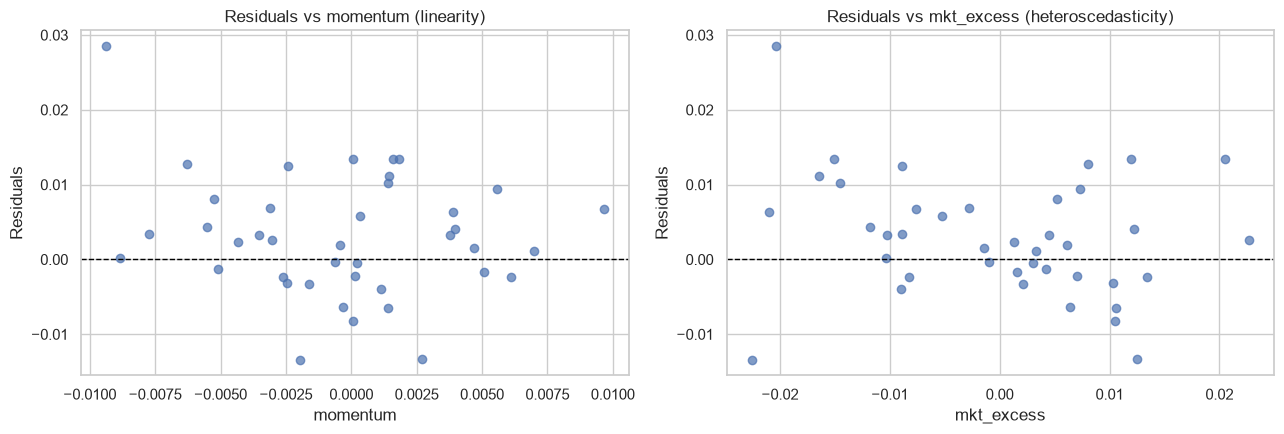

In [7]:
# Linearity: residuals vs momentum (the omitted quadratic predictor).
# Heteroscedasticity: residuals vs mkt_excess (the variance driver).
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(X_test['momentum'], resid, alpha=0.7)
axes[0].axhline(0, color='black', ls='--', lw=1)
axes[0].set_xlabel('momentum')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs momentum (linearity)')

axes[1].scatter(X_test['mkt_excess'], resid, alpha=0.7)
axes[1].axhline(0, color='black', ls='--', lw=1)
axes[1].set_xlabel('mkt_excess')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs mkt_excess (heteroscedasticity)')

fig.tight_layout()
plt.show()

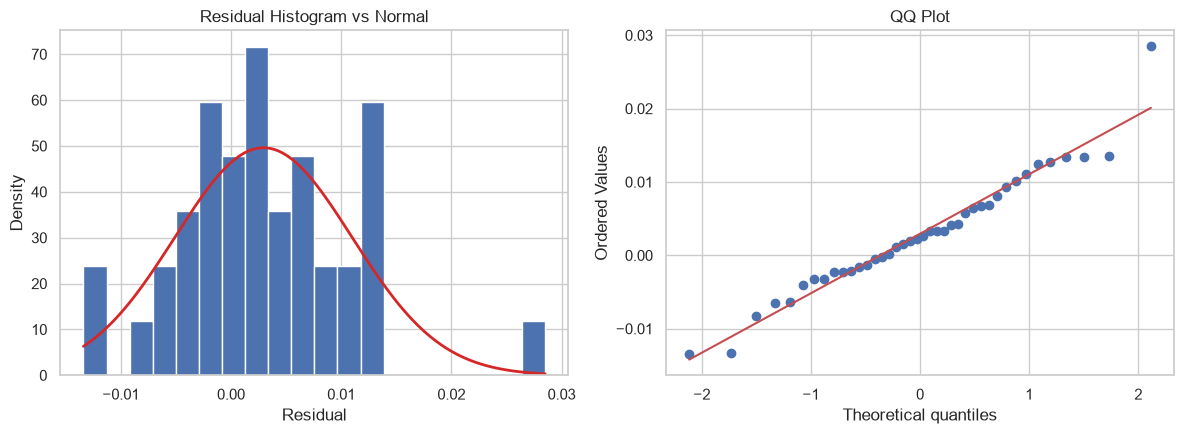

In [8]:
# Assumption 3: normality — histogram + QQ plot.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(resid, bins=20, density=True, edgecolor='white')
xs = np.linspace(resid.min(), resid.max(), 200)
axes[0].plot(xs, st.norm.pdf(xs, loc=resid.mean(), scale=resid.std()), color='tab:red', lw=2)
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Density')
axes[0].set_title('Residual Histogram vs Normal')

st.probplot(resid, dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot')

fig.tight_layout()
plt.show()

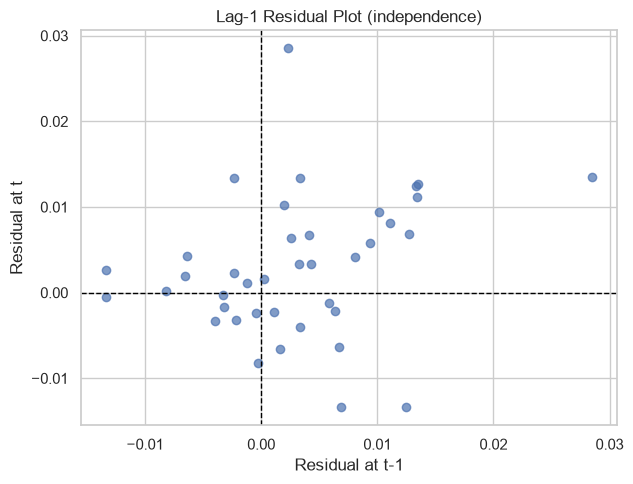

In [9]:
# Assumption 4: independence — residual at t vs residual at t-1.
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(resid[:-1], resid[1:], alpha=0.7)
ax.axhline(0, color='black', ls='--', lw=1)
ax.axvline(0, color='black', ls='--', lw=1)
ax.set_xlabel('Residual at t-1')
ax.set_ylabel('Residual at t')
ax.set_title('Lag-1 Residual Plot (independence)')
fig.tight_layout()
plt.show()

## 4) Interpretation of the assumptions

**Linearity — mildly violated, but the effect is negligible.** The residuals-vs-`momentum` panel shows
a faint U-shape, and `corr(residual, momentum^2) = +0.34` confirms the omitted quadratic term is
leaking into the residuals. But look at the *size* of the effect: `momentum` has standard deviation
0.006, so `momentum^2` is on the order of 3.6e-5 and `3.5 * momentum^2` contributes ~0.0001 on
average versus noise with standard deviation ~0.008. The curvature is real but swamped by noise.

**Homoscedasticity — clearly violated (the dominant problem).** `corr(|residual|, |mkt_excess|) = +0.57`,
and the residual-vs-fitted and residual-vs-`mkt_excess` panels both fan out: the spread is smallest
near `mkt_excess ≈ 0` and widens with `|mkt_excess|`. That is by construction (`noise_scale = 0.0035 +
0.5 |mkt_excess|`), and it is the largest violation in this model.

**Normality — roughly OK, with heavy tails.** Skewness is +0.51 and excess kurtosis +1.22, so the
residuals are heavier-tailed than a normal, and the QQ plot bends away from the 45-degree line at the
ends. The Shapiro-Wilk p-value (0.24) does *not* reject normality. The heavy tails are a symptom of
the heteroscedasticity: the residuals are a mixture of low-noise and high-noise normals, which thickens
the tails without adding skew.

**Independence — satisfied.** The lag-1 autocorrelation is +0.26, inside the ±0.31 white-noise band for
a test set of n=40, so there is no significant serial correlation in the errors. The residual lag-1
scatter is a cloud with no trend. (This is expected: the DGP errors are independent draws.)

## 5) Stretch — add a squared term (and why this is still linear regression)

Adding `momentum^2` is a *nonlinear transformation of a feature*, but the model remains **linear in its
parameters**: `y = b0 + b1*mkt + b2*size + b3*value + b4*momentum + b5*momentum^2 + e`. It is still a
linear regression because the response is a linear function of the *coefficients*; `momentum^2` is just
another column in the design matrix (the same idea as stage 09's engineered features).

In [10]:
df['momentum_sq'] = df['momentum'] ** 2
X2 = df[['mkt_excess', 'size', 'value', 'momentum', 'momentum_sq']]
X2_train, X2_test = X2.iloc[:len(X_train)], X2.iloc[len(X_train):]
lr2 = LinearRegression().fit(X2_train, y_train)
y_pred2 = lr2.predict(X2_test)
resid2 = y_test - y_pred2
r2_2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))

print(f'Baseline      R2={r2:.4f}   RMSE={rmse:.6f}')
print(f'With momentum^2  R2={r2_2:.4f}   RMSE={rmse_2:.6f}')
print('\nmomentum_sq coefficient: %.4f   (true 3.5)' % lr2.coef_[-1])
print('heteroscedasticity after adding x^2: corr(|resid|, |mkt_excess|) = %.3f'
      % np.corrcoef(np.abs(resid2), np.abs(X_test['mkt_excess']))[0, 1])

Baseline      R2=0.3677   RMSE=0.008470
With momentum^2  R2=0.3681   RMSE=0.008467

momentum_sq coefficient: 20.2317   (true 3.5)
heteroscedasticity after adding x^2: corr(|resid|, |mkt_excess|) = 0.575


## 6) Metrics — what R² and RMSE actually tell us

`R² = 0.37` says the model explains about 37% of the variance in the test outcomes. `RMSE = 0.0085` is
the more decision-relevant number: the test outcome has standard deviation ~0.0108, so the model's
typical error is still ~79% of the raw variation. In other words, the model is meaningfully better
than a mean-only baseline (which would give RMSE ≈ the standard deviation, 0.0108) — it cuts error by
roughly a fifth — but a large, irreducible, *heteroskedastic* noise component remains, and no amount
of feature surgery on the mean will remove it.

**Explanation vs prediction.** This is the key distinction for trust:

- **Prediction** is fair: R² and RMSE are computed on an unseen, time-ordered test window, so they
  reflect out-of-sample accuracy, and the model is useful for ranking/estimating expected returns.
- **Explanation** is weak: the coefficient estimates are biased by the omitted quadratic term and the
  heteroscedasticity (`mkt_excess` 0.78 vs true 0.9, `momentum` 0.18 vs true 0.35). So I would *not*
  read the coefficients as clean estimates of the true factor exposures.

The added `momentum^2` barely moves the metrics (R² 0.3677 → 0.3681), which is consistent with the
diagnosis above: the nonlinearity is real but tiny relative to the noise, and it does nothing for the
heteroscedasticity (the `|resid|`–`|mkt_excess|` correlation is unchanged at ~0.57).

## 7) Conclusion — do I trust this model?

**Partially, and only for prediction, not explanation.** The model's point predictions are reasonable
(out-of-sample R² ≈ 0.37, RMSE ≈ 0.0085, better than a mean-only baseline), and its errors look
independent. But two assumptions fail — heteroscedasticity (strongly) and linearity (mildly) — so the
coefficients should not be treated as reliable estimates of the true factor exposures, and the
uncertainty is not constant across the market regime (it is largest exactly when `|mkt_excess|` is
large, i.e. in the riskiest states).

**Next steps I would try:** (1) address the heteroscedasticity directly with weighted least squares or
robust standard errors if inference matters; (2) standardize the factors so the tiny-scale `momentum`
does not produce unstable coefficients; (3) if the goal is purely prediction, compare against a
model that can model the changing variance (e.g., a GARCH-type or quantile model) rather than
chasing a higher R² with more mean-terms.